## Derm1M dataset

Fetching individual images via streamed remote zipfile...
[SUCCESS] Downloaded: OzBKmWt9zWo_frame_8071_0_0.jpg to derm_train_images/youtube/OzBKmWt9zWo_frame_8071_0_0.jpg


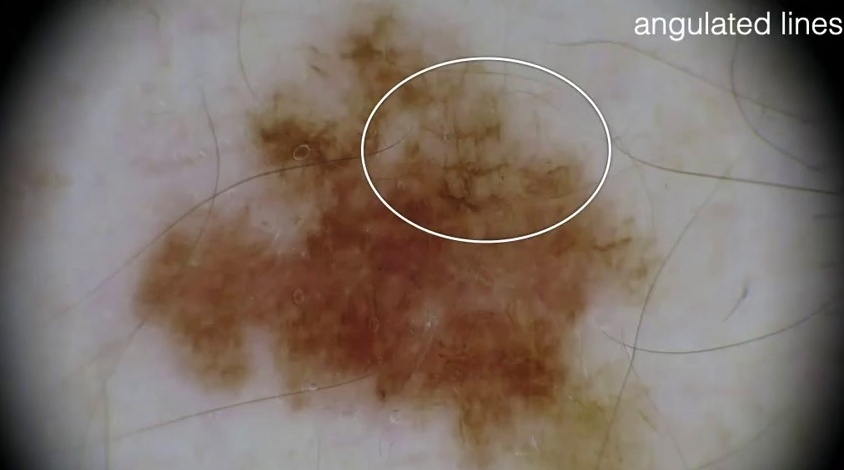

In [17]:
import io
import os
import zipfile
from PIL import Image
from huggingface_hub import HfFileSystem

# Initialize the file system 
fs = HfFileSystem()

pubmed_filenames = [
    "00_39_PMC10381143_jimaging-09-00148-g011_1.jpg",
    "00_39_PMC10381143_jimaging-09-00148-g012_1.jpg",
    "0d_59_PMC4458964_IJD_60_321e_g003_0.png"
]

IYII_filenames = [
    "2281_1.png"
]

youtube_filenames = [
    "OzBKmWt9zWo_frame_8071_0_0.jpg"
]

repo_id = "datasets/redlessone/Derm1M"
downloaded_images = {}

print("Fetching individual images via streamed remote zipfile...")

download_tasks = {
    # "pubmed": pubmed_filenames,
    # "IIYI": IYII_filenames,
    "youtube": youtube_filenames
}

for category, filenames in download_tasks.items():
    zip_name = f"{category}.zip"
    remote_zip_path = f"{repo_id}/{zip_name}"
    
    try:
        with fs.open(remote_zip_path, "rb") as remote_file:
            with zipfile.ZipFile(remote_file) as zf:
                
                for filename in filenames:
                    internal_path = f"{filename}"
                    
                    try:
                        with zf.open(internal_path) as img_file:
                            img = Image.open(io.BytesIO(img_file.read())).convert("RGB")
                            
                            downloaded_images[filename] = img
                            
                            local_save_path = f"derm_train_images/{category}/{filename}"
                            os.makedirs(os.path.dirname(local_save_path), exist_ok=True)
                            img.save(local_save_path)
                            
                            print(f"[SUCCESS] Downloaded: {filename} to {local_save_path}")
                            
                    except KeyError:
                        print(f"[ERROR] File '{internal_path}' does not exist inside '{zip_name}'.")
                    except Exception as e:
                        print(f"[ERROR] Failed to download {internal_path}: {e}")
                        
    except Exception as e:
        print(f"[ERROR] Could not open remote zip '{remote_zip_path}': {e}")

if downloaded_images:
    first_image = list(downloaded_images.values())[0]
    display(first_image)

# Downloading additional datasets

In [58]:
sample_number = 25 # musi się dzielić przez 5!!!

In [42]:
from remotezip import RemoteZip
from sympy import content
import os
from pathlib import Path
import random

def download_imgs (url, dir_name, samples_no, forbidden=[]):
    directory = Path(dir_name) 
    paths = []
    with RemoteZip(url) as z:
        files = [f for f in z.namelist() if not f.endswith("/")]
        files = [
            f for f in files
            if not any(os.path.basename(f).startswith(prefix) for prefix in forbidden)
        ]

        sample_size = min(samples_no, len(files))
        random_files = random.sample(files, sample_size)

        for path in random_files:
            paths.append(path)
            dest = directory / os.path.basename(path)
            dest.parent.mkdir(parents=True, exist_ok=True)
            with z.open(path) as src, open(dest, "wb") as dst:
                dst.write(src.read())
                print(f"Downloaded {path} to {dest}")
                
    return paths
    



## PAD dataset

In [53]:
directory = "pad_images"

In [ ]:
url = "https://prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com/4ea8d71a-260e-4f97-a977-2c426ae6d4a4"
_ = download_imgs(url, directory, sample_number)

Downloaded imgs_part_1/PAT_34_47_108.png to pad_images\PAT_34_47_108.png
Downloaded imgs_part_1/PAT_159_245_181.png to pad_images\PAT_159_245_181.png
Downloaded imgs_part_1/PAT_115_1138_870.png to pad_images\PAT_115_1138_870.png
Downloaded imgs_part_1/PAT_20_30_44.png to pad_images\PAT_20_30_44.png
Downloaded imgs_part_1/PAT_359_741_973.png to pad_images\PAT_359_741_973.png
Downloaded imgs_part_1/PAT_166_257_586.png to pad_images\PAT_166_257_586.png
Downloaded imgs_part_1/PAT_269_415_103.png to pad_images\PAT_269_415_103.png
Downloaded imgs_part_1/PAT_514_967_908.png to pad_images\PAT_514_967_908.png
Downloaded imgs_part_1/PAT_388_1590_169.png to pad_images\PAT_388_1590_169.png
Downloaded imgs_part_1/PAT_464_899_646.png to pad_images\PAT_464_899_646.png


In [55]:
!curl -o "metadata.csv" "https://prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com/de867406-1a86-4eb7-bffa-3db4ab357f3f"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  308k  100  308k    0     0   817k      0 --:--:-- --:--:-- --:--:--  821k


In [56]:
# creating meta file for imgs

import pandas as pd
import os

df = pd.read_csv("metadata.csv")

if os.path.exists(os.path.join(directory, "meta.csv")):
    os.remove(os.path.join(directory, "meta.csv"))
    
img_names = []

for img_name in os.listdir(directory):
    img_names.append(img_name)

chosen = df[df["img_id"].isin(img_names)]
chosen["filename"] = chosen["img_id"]

skin_lesions = {
    "BCC": "Basal Cell Carcinoma",
    "SCC": "Squamous Cell Carcinoma",
    "ACK": "Actinic Keratosis",
    "SEK": "Seborrheic Keratosis",
    "MEL": "Melanoma",
    "NEV": "Nevus"
}
labels = list(skin_lesions.values()) # WAZNE
chosen["label"] = chosen["diagnostic"].map(skin_lesions)
chosen = chosen[["filename", "label"]]
chosen.to_csv(os.path.join(directory, "meta.csv"), index=False) 
os.remove("metadata.csv")

In [57]:
pad_labels = [
    "Basal Cell Carcinoma",
    "Squamous Cell Carcinoma",
    "Actinic Keratosis",
    "Seborrheic Keratosis",
    "Melanoma",
    "Nevus"
]

## Daffodil International University dataset

In [50]:
directory = "daffodil_images"

In [ ]:
urls = ["https://prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com/5aca09ba-1b5a-4564-aa2f-88b6df0ccb4f", 
        "https://prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com/ed53b1d3-d6b4-4d8e-9704-68a57a875e0b", 
        "https://prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com/a035eab7-4cf8-4590-8b9a-2ecf4ae315f1", 
        "https://prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com/6b6cbf5e-47f0-4d58-af85-435ae786a0fb", 
        "https://prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com/4e221083-4f36-4d33-90b6-c12fe5561441"]

daffodil_labels = ["acne", 
          "hyperpigmentation",
          "nail psoriasis",
          "sjs ten", 
          "vitiligo"]

all_imgs_names = []
for url, label in zip(urls, daffodil_labels):
    imgs_names = download_imgs(url, directory, sample_number/5, ['padd', 'saturation','superpixels', 'hue'])
    all_imgs_names.append(imgs_names)

Downloaded acne/Resize-450_400193__ProtectWyJQcm90ZWN0Il0_FocusFillWzI5NCwyMjIsIngiLDFd.jpg to daffodil_images\Resize-450_400193__ProtectWyJQcm90ZWN0Il0_FocusFillWzI5NCwyMjIsIngiLDFd.jpg
Downloaded acne/195__ProtectWyJQcm90ZWN0Il0_FocusFillWzI5NCwyMjIsIngiLDFd.jpg to daffodil_images\195__ProtectWyJQcm90ZWN0Il0_FocusFillWzI5NCwyMjIsIngiLDFd.jpg
Downloaded hyperpigmentation/Crop-0350_100400acquired-dermal-macular-hyperpigmentation-012__ProtectWyJQcm90ZWN0Il0_FocusFillWzI5NCwyMjIsIngiLDFd.jpeg to daffodil_images\Crop-0350_100400acquired-dermal-macular-hyperpigmentation-012__ProtectWyJQcm90ZWN0Il0_FocusFillWzI5NCwyMjIsIngiLDFd.jpeg
Downloaded hyperpigmentation/flip--1acquired-dermal-macular-hyperpigmentation-004__ProtectWyJQcm90ZWN0Il0_FocusFillWzI5NCwyMjIsIngiLDFd.jpeg to daffodil_images\flip--1acquired-dermal-macular-hyperpigmentation-004__ProtectWyJQcm90ZWN0Il0_FocusFillWzI5NCwyMjIsIngiLDFd.jpeg
Downloaded Nail_psoriasis/flip-03257__ProtectWyJQcm90ZWN0Il0_FocusFillWzI5NCwyMjIsIngiLDFd.j

In [52]:
# creating meta file for imgs
rows = []

for label, img_names in zip(daffodil_labels, all_imgs_names):
    for name in img_names:
        rows.append({"filename": name, "label": label})

df = pd.DataFrame(rows)

df.to_csv(os.path.join(directory, "meta.csv"), index=False)

# MONET Model

In [1]:
from transformers import AutoProcessor, AutoModelForZeroShotImageClassification

processor = AutoProcessor.from_pretrained("suinleelab/monet")
model = AutoModelForZeroShotImageClassification.from_pretrained("suinleelab/monet")

c:\Users\asiaa\OneDrive\Desktop\Studia\Sezon 7\XAI\derm-overview\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\asiaa\OneDrive\Desktop\Studia\Sezon 7\XAI\derm-overview\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\asiaa\.cache\huggingface\hub\models--suinleelab--monet. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mod

                                            filename label
0  acne_144__ProtectWyJQcm90ZWN0Il0_FocusFillWzI5...  acne
1  acne_154__ProtectWyJQcm90ZWN0Il0_FocusFillWzI5...  acne
2  acne_171__ProtectWyJQcm90ZWN0Il0_FocusFillWzI5...  acne
3  acne_182__ProtectWyJQcm90ZWN0Il0_FocusFillWzI5...  acne
4  acne_193__ProtectWyJQcm90ZWN0Il0_FocusFillWzI5...  acne


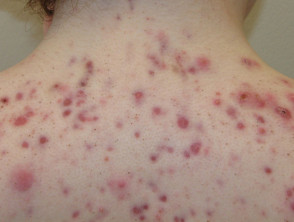

Label: acne


In [10]:
import pandas as pd
import os
from PIL import Image
directory = "daffodil_images"

meta = pd.read_csv(os.path.join(directory, "meta.csv"))
print(meta.head())
img_path = os.path.join(directory, meta.iloc[0]['filename'])
img = Image.open(img_path).convert("RGB")
label = meta.iloc[0]['label']
display(img)
print(f"Label: {label}")

In [ ]:
import torch
model.eval()

daffodil_labels = [
    "acne",
    "hyperpigmentation",
    "nail psoriasis",
    "sjs ten", 
    "vitiligo"
]

inputs = processor(
    images=img,
    text=daffodil_labels,
    return_tensors="pt",
    padding=True
)

with torch.no_grad():
    outputs = model(**inputs)
    

print(outputs)

CLIPOutput(loss=None, logits_per_image=tensor([[32.2339, 26.9494, 22.2684, 28.8214, 25.1216]]), logits_per_text=tensor([[32.2339],
        [26.9494],
        [22.2684],
        [28.8214],
        [25.1216]]), text_embeds=tensor([[-0.0086,  0.0340,  0.0150,  ..., -0.0060, -0.0012, -0.0220],
        [-0.0361,  0.0591, -0.0020,  ..., -0.0264,  0.0207,  0.0243],
        [-0.0109,  0.0202, -0.0269,  ...,  0.0124,  0.0334, -0.0113],
        [-0.0005,  0.0548, -0.0418,  ..., -0.0014, -0.0029, -0.0352],
        [ 0.0051,  0.0537, -0.0030,  ..., -0.0026,  0.0101,  0.0102]]), image_embeds=tensor([[ 1.5615e-02,  9.1781e-02,  2.4979e-02,  3.1453e-02, -1.5696e-02,
         -2.1619e-02, -1.0667e-02,  6.3974e-02,  1.6011e-02, -4.9491e-02,
          1.1850e-02, -2.4691e-02, -1.7824e-02,  3.1296e-02,  2.8528e-02,
         -1.4453e-02,  1.1595e-02, -8.1918e-06, -3.9903e-03, -1.8816e-02,
          2.9818e-02, -2.2254e-02, -1.3955e-02, -7.4584e-03, -2.5396e-02,
          2.3753e-02,  5.4568e-02,  7.1579e-